## 1. Cài đặt & Import

In [ ]:
!pip install -q kagglehub nltk Pillow tqdm
print('Xong!')

✅ Xong!


In [ ]:
import os, random, json
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.nn.utils.rnn import pack_padded_sequence

import torchvision.transforms as transforms
import torchvision.models as models

import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

🖥️  Device: cuda
   GPU: Tesla T4


## 2. Tải Dataset (kagglehub)

In [ ]:
import kagglehub

path = kagglehub.dataset_download('hsankesara/flickr-image-dataset')
print('Path to dataset files:', path)

DATASET_ROOT  = Path(path)
IMAGES_DIR    = DATASET_ROOT / 'flickr30k_images' / 'flickr30k_images'
CAPTIONS_FILE = DATASET_ROOT / 'flickr30k_images' / 'results.csv'

print(f'Ảnh     : {IMAGES_DIR}')
print(f'Captions: {CAPTIONS_FILE}')

Using Colab cache for faster access to the 'flickr-image-dataset' dataset.
Path to dataset files: /kaggle/input/flickr-image-dataset
🖼️  Ảnh     : /kaggle/input/flickr-image-dataset/flickr30k_images/flickr30k_images
📝 Captions: /kaggle/input/flickr-image-dataset/flickr30k_images/results.csv


## 🔍 3. Load & Khám phá Dataset

In [ ]:
df = pd.read_csv(
    CAPTIONS_FILE, sep='|', skipinitialspace=True,
    header=0, names=['image_name', 'caption_idx', 'caption']
)
df = df[df['caption_idx'].astype(str).str.strip().str.match(r'^\d+$')].copy()
df['caption_idx'] = df['caption_idx'].astype(int)
df['image_name']  = df['image_name'].str.strip()
df['caption']     = df['caption'].str.strip()
df = df.reset_index(drop=True)

print(f'Tổng số dòng  : {len(df):,}')
print(f'Số ảnh unique : {df["image_name"].nunique():,}')
df.head(6)

✅ Tổng số dòng  : 158,914
   Số ảnh unique : 31,783


,image_name,caption_idx,caption
0,1000092795.jpg,0,Two young guys with shaggy hair look at their ...
1,1000092795.jpg,1,"Two young , White males are outside near many ..."
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .
4,1000092795.jpg,4,Two friends enjoy time spent together .
5,10002456.jpg,0,Several men in hard hats are operating a giant...


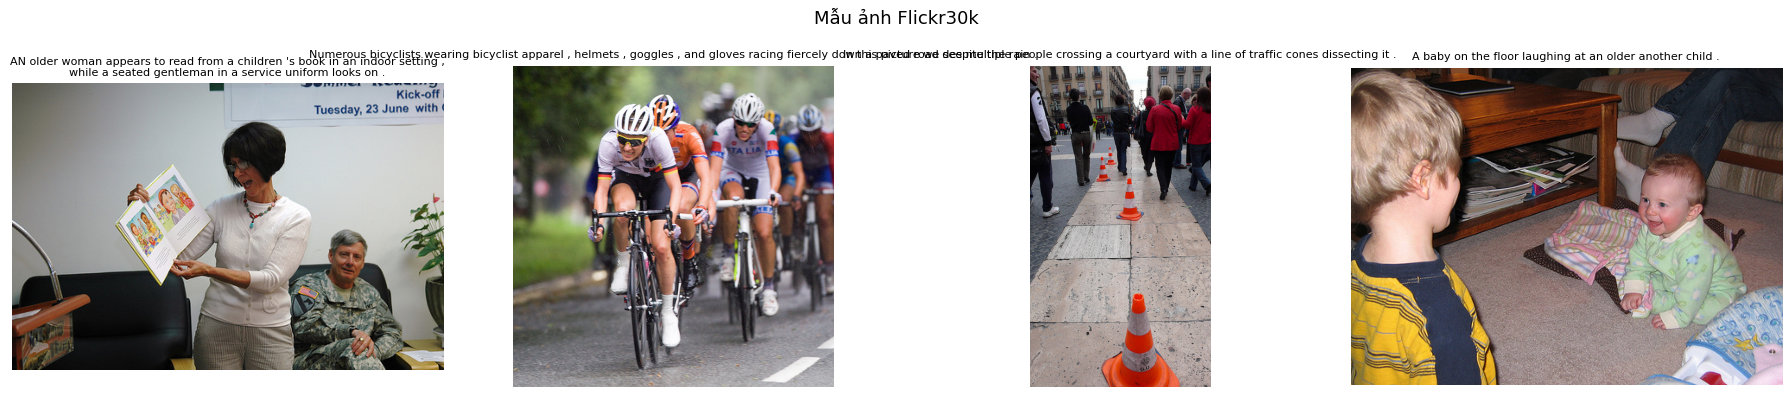

In [ ]:
# Hiển thị mẫu ảnh
samples = df['image_name'].drop_duplicates().sample(4, random_state=SEED).tolist()
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, img_name in zip(axes, samples):
    img = Image.open(IMAGES_DIR / img_name).convert('RGB')
    cap = df[df['image_name'] == img_name]['caption'].iloc[0]
    ax.imshow(img); ax.axis('off')
    ax.set_title(cap, fontsize=8, wrap=True)
plt.suptitle('Mẫu ảnh Flickr30k', fontsize=13)
plt.tight_layout(); plt.show()

## 4. Chia Train / Val / Test (8:1:1)

In [ ]:
all_images = df['image_name'].drop_duplicates().tolist()
random.shuffle(all_images)

n_total = len(all_images)
n_train = int(n_total * 0.8)
n_val   = int(n_total * 0.1)
n_test  = n_total - n_train - n_val

train_imgs = set(all_images[:n_train])
val_imgs   = set(all_images[n_train:n_train + n_val])
test_imgs  = set(all_images[n_train + n_val:])

train_df = df[df['image_name'].isin(train_imgs)].reset_index(drop=True)
val_df   = df[df['image_name'].isin(val_imgs)].reset_index(drop=True)
test_df  = df[df['image_name'].isin(test_imgs)].reset_index(drop=True)

print(f'Train : {len(train_imgs):,} ảnh | {len(train_df):,} captions')
print(f'Val   : {len(val_imgs):,} ảnh | {len(val_df):,} captions')
print(f'Test  : {len(test_imgs):,} ảnh | {len(test_df):,} captions')

Train : 25,426 ảnh | 127,129 captions
Val   : 3,178 ảnh | 15,890 captions
Test  : 3,179 ảnh | 15,895 captions


## 5. Xây dựng Vocabulary

In [ ]:
import sys
from pathlib import Path
from collections import Counter

# Import Vocabulary từ build_vocab.py
import sys
sys.path.insert(0, '/workspaces/Tri-tue-nhan-tao')
from build_vocab import Vocabulary

# Load vocab đã build sẵn từ file pkl
vocab_pkl_path = Path('/workspaces/Tri-tue-nhan-tao/vocab.pkl')
print("📦 Load vocab từ file pickle...")
import pickle
with open(vocab_pkl_path, 'rb') as f:
    vocab = pickle.load(f)
print(f"✓ Loaded vocab: {len(vocab):,} từ")

# Demo
print(f"\n🎯 Vocab stats:")
print(f"   Size: {len(vocab):,}")
print(f"   Special tokens: PAD={vocab.PAD}, SOS={vocab.SOS}, EOS={vocab.EOS}, UNK={vocab.UNK}")
sample_cap = "a dog is running in the park"
encoded = vocab.encode(sample_cap)
decoded = vocab.decode(encoded)
print(f"\n📝 Demo:")
print(f"   Input:   '{sample_cap}'")
print(f"   Encoded: {encoded[:5]}... (first 5)")
print(f"   Decoded: '{decoded}'")

✅ Vocab size: 7,009 từ (freq_threshold=5)
💾 Vocab saved to /content/vocab.json


## 6. Config & Dataset

In [ ]:
CFG = {
    # Model
    'embed_dim'   : 256,    # chiều embedding từ
    'hidden_dim'  : 512,    # chiều hidden LSTM
    'num_layers'  : 1,      # số layer LSTM
    'dropout'     : 0.5,
    # Training
    'batch_size'  : 32,
    'num_workers' : 0,      # 0 = ổn định trên Colab
    'lr'          : 3e-4,
    'epochs'      : 20,
    'patience'    : 4,      # early stopping
    'max_length'  : 40,     # độ dài caption tối đa
    'grad_clip'   : 5.0,
    # Image
    'img_size'    : 224,
}


def get_transforms(train=True):
    if train:
        return transforms.Compose([
            transforms.Resize((CFG['img_size'] + 32, CFG['img_size'] + 32)),
            transforms.RandomCrop(CFG['img_size']),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
    return transforms.Compose([
        transforms.Resize((CFG['img_size'], CFG['img_size'])),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])


class Flickr30kDataset(Dataset):
    def __init__(self, dataframe, images_dir, vocab, transform=None,
                 max_length=40):
        self.data       = dataframe.reset_index(drop=True)
        self.images_dir = Path(images_dir)
        self.vocab      = vocab
        self.transform  = transform
        self.max_length = max_length

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        row   = self.data.iloc[idx]
        image = Image.open(self.images_dir / row['image_name']).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # Encode caption
        tokens = self.vocab.encode(row['caption'])
        # Truncate & pad đến max_length+1 (bao gồm SOS)
        tokens = tokens[:self.max_length + 1]
        length = len(tokens)  # độ dài thực (có SOS, có EOS nếu còn chỗ)

        caption = torch.zeros(self.max_length + 1, dtype=torch.long)
        caption[:length] = torch.tensor(tokens)

        return image, caption, torch.tensor(length)


train_dataset = Flickr30kDataset(train_df, IMAGES_DIR, vocab,
                                  get_transforms(train=True), CFG['max_length'])
val_dataset   = Flickr30kDataset(val_df,   IMAGES_DIR, vocab,
                                  get_transforms(train=False), CFG['max_length'])
test_dataset  = Flickr30kDataset(test_df,  IMAGES_DIR, vocab,
                                  get_transforms(train=False), CFG['max_length'])

train_loader = DataLoader(train_dataset, batch_size=CFG['batch_size'],
                          shuffle=True,  num_workers=CFG['num_workers'], pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=CFG['num_workers'], pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=CFG['num_workers'], pin_memory=True)

print(f'Train: {len(train_loader):,} batches')
print(f'Val  : {len(val_loader):,} batches')
print(f'Test : {len(test_loader):,} batches')

✅ Train: 3,973 batches
   Val  : 497 batches
   Test : 497 batches


## 7. Model: CNN Encoder + LSTM Decoder

In [ ]:
class CNNEncoder(nn.Module):
    """
    ResNet50 pretrained (frozen) + FC layer → embed_dim vector
    """
    def __init__(self, embed_dim: int):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Bỏ layer classification cuối
        modules = list(resnet.children())[:-1]
        self.backbone = nn.Sequential(*modules)   # output: (B, 2048, 1, 1)

        # Freeze toàn bộ ResNet
        for param in self.backbone.parameters():
            param.requires_grad = False

        # FC để chiếu về embed_dim
        self.fc      = nn.Linear(2048, embed_dim)
        self.bn      = nn.BatchNorm1d(embed_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, images):                     # (B, 3, 224, 224)
        with torch.no_grad():
            features = self.backbone(images)       # (B, 2048, 1, 1)
        features = features.view(features.size(0), -1)  # (B, 2048)
        features = self.dropout(self.bn(self.fc(features)))  # (B, embed_dim)
        return features


class LSTMDecoder(nn.Module):
    """
    LSTM Decoder sinh caption từng token một.
    Input:  encoder_out (B, embed_dim) + caption tokens
    Output: logits (B, seq_len, vocab_size)
    """
    def __init__(self, embed_dim, hidden_dim, vocab_size,
                 num_layers=1, dropout=0.5):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm    = nn.LSTM(embed_dim, hidden_dim, num_layers,
                               batch_first=True,
                               dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc_out  = nn.Linear(hidden_dim, vocab_size)

        # Chiếu encoder feature → hidden state khởi tạo
        self.init_h  = nn.Linear(embed_dim, hidden_dim)
        self.init_c  = nn.Linear(embed_dim, hidden_dim)

    def forward(self, encoder_out, captions, lengths):
        """
        encoder_out : (B, embed_dim)
        captions    : (B, max_len+1)  — bao gồm SOS ở đầu
        lengths     : (B,)            — độ dài thực mỗi caption
        """
        B = encoder_out.size(0)

        # Khởi tạo hidden state từ encoder
        h0 = self.init_h(encoder_out).unsqueeze(0)  # (1, B, hidden_dim)
        c0 = self.init_c(encoder_out).unsqueeze(0)

        # Embed captions (bỏ token cuối — không cần input EOS)
        embeddings = self.dropout(self.embed(captions[:, :-1]))  # (B, max_len, embed_dim)

        # Pack để bỏ qua padding
        packed = pack_padded_sequence(
            embeddings,
            (lengths - 1).clamp(min=1).cpu(),
            batch_first=True, enforce_sorted=False
        )
        out, _ = self.lstm(packed, (h0, c0))

        # Unpack
        from torch.nn.utils.rnn import pad_packed_sequence
        out, _ = pad_packed_sequence(out, batch_first=True)  # (B, T, hidden_dim)

        logits = self.fc_out(self.dropout(out))  # (B, T, vocab_size)
        return logits

    @torch.no_grad()
    def generate(self, encoder_out, vocab, max_length=40):
        """Greedy search — sinh 1 caption."""
        B  = encoder_out.size(0)
        h  = self.init_h(encoder_out).unsqueeze(0)
        c  = self.init_c(encoder_out).unsqueeze(0)

        token = torch.full((B, 1), vocab.SOS, dtype=torch.long, device=encoder_out.device)
        results = [[] for _ in range(B)]
        done    = [False] * B

        for _ in range(max_length):
            emb = self.embed(token)          # (B, 1, embed_dim)
            out, (h, c) = self.lstm(emb, (h, c))
            logit = self.fc_out(out.squeeze(1))  # (B, vocab_size)
            token = logit.argmax(dim=1, keepdim=True)  # (B, 1)

            for i in range(B):
                if not done[i]:
                    t = token[i].item()
                    if t == vocab.EOS:
                        done[i] = True
                    else:
                        results[i].append(t)

            if all(done): break

        return [vocab.decode(r) for r in results]


class CNNLSTMCaptioner(nn.Module):
    def __init__(self, embed_dim, hidden_dim, vocab_size,
                 num_layers=1, dropout=0.5):
        super().__init__()
        self.encoder = CNNEncoder(embed_dim)
        self.decoder = LSTMDecoder(embed_dim, hidden_dim, vocab_size,
                                   num_layers, dropout)

    def forward(self, images, captions, lengths):
        features = self.encoder(images)
        logits   = self.decoder(features, captions, lengths)
        return logits


# ── Khởi tạo ──────────────────────────────────────────────
model = CNNLSTMCaptioner(
    embed_dim  = CFG['embed_dim'],
    hidden_dim = CFG['hidden_dim'],
    vocab_size = len(vocab),
    num_layers = CFG['num_layers'],
    dropout    = CFG['dropout'],
).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Tổng params     : {total/1e6:.1f}M')
print(f'Trainable       : {trainable/1e6:.1f}M  (ResNet frozen)')
print(f'Frozen (ResNet) : {(total-trainable)/1e6:.1f}M')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 232MB/s]


📊 Tổng params     : 31.3M
   Trainable       : 7.8M  (ResNet frozen)
   Frozen (ResNet) : 23.5M


## 8. Loss, Optimizer, Scheduler

In [ ]:
# Loss: bỏ qua PAD (index=0)
criterion = nn.CrossEntropyLoss(ignore_index=vocab.PAD)

# Chỉ optimize phần trainable (Decoder + FC encoder)
optimizer = Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG['lr']
)

# ReduceLROnPlateau: giảm lr khi val_loss không cải thiện
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

# AMP
scaler = torch.cuda.amp.GradScaler()

print(f'Loss      : CrossEntropyLoss (ignore PAD)')
print(f'Optimizer : Adam (lr={CFG["lr"]})')
print(f'Scheduler : ReduceLROnPlateau (factor=0.5, patience=2)')
print(f'AMP       : Enabled')

✅ Loss      : CrossEntropyLoss (ignore PAD)
   Optimizer : Adam (lr=0.0003)
   Scheduler : ReduceLROnPlateau (factor=0.5, patience=2)
   AMP       : Enabled


## 9. Training Loop

In [ ]:
CHECKPOINT_DIR = Path('/content/cnn_lstm_checkpoints')
CHECKPOINT_DIR.mkdir(exist_ok=True)


def train_epoch(model, loader, optimizer, criterion, scaler, epoch):
    model.train()
    total_loss = 0.0
    pbar = tqdm(loader, desc=f'Epoch {epoch} [Train]', leave=False)

    for images, captions, lengths in pbar:
        images   = images.to(DEVICE)
        captions = captions.to(DEVICE)
        lengths  = lengths.to(DEVICE)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            logits = model(images, captions, lengths)  # (B, T, vocab_size)

            # Targets: caption bỏ SOS đầu → từ index 1 trở đi
            T = logits.size(1)
            targets = captions[:, 1:T+1]               # (B, T)

            loss = criterion(
                logits.reshape(-1, len(vocab)),
                targets.reshape(-1)
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            filter(lambda p: p.requires_grad, model.parameters()),
            CFG['grad_clip']
        )
        scaler.step(optimizer); scaler.update()

        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / len(loader)


@torch.no_grad()
def validate_epoch(model, loader, criterion, epoch):
    model.eval()
    total_loss = 0.0
    pbar = tqdm(loader, desc=f'Epoch {epoch} [Val]', leave=False)

    for images, captions, lengths in pbar:
        images   = images.to(DEVICE)
        captions = captions.to(DEVICE)
        lengths  = lengths.to(DEVICE)

        with torch.cuda.amp.autocast():
            logits  = model(images, captions, lengths)
            T       = logits.size(1)
            targets = captions[:, 1:T+1]
            loss    = criterion(logits.reshape(-1, len(vocab)), targets.reshape(-1))

        total_loss += loss.item()
        pbar.set_postfix({'val_loss': f'{loss.item():.4f}'})

    return total_loss / len(loader)

In [ ]:
history = {'train_loss': [], 'val_loss': [], 'lr': []}
best_val_loss    = float('inf')
patience_counter = 0

print('Bắt đầu training CNN + LSTM\n')
print(f'Epochs   : {CFG["epochs"]}  |  Patience: {CFG["patience"]}')
print(f'Batch    : {CFG["batch_size"]}  |  lr: {CFG["lr"]}')
print(f'Vocab    : {len(vocab):,} từ\n')

for epoch in range(1, CFG['epochs'] + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, scaler, epoch)
    val_loss   = validate_epoch(model, val_loader, criterion, epoch)
    current_lr = optimizer.param_groups[0]['lr']

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['lr'].append(current_lr)

    print(f'Epoch [{epoch:2d}/{CFG["epochs"]}]  '
          f'Train: {train_loss:.4f}  |  Val: {val_loss:.4f}  |  lr: {current_lr:.2e}')

    # ── Best model & Early Stopping ───────────────────────
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save({
            'epoch'     : epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss'  : val_loss,
            'vocab'     : vocab.word2idx,
        }, CHECKPOINT_DIR / 'best_model.pt')
        print(f'Best! Val Loss: {val_loss:.4f}')
    else:
        patience_counter += 1
        print(f'No improvement ({patience_counter}/{CFG["patience"]})')
        if patience_counter >= CFG['patience']:
            print(f'\n Early Stopping tại Epoch {epoch}!')
            break

print('\n Training hoàn tất!')

🚀 Bắt đầu training CNN + LSTM

   Epochs   : 20  |  Patience: 4
   Batch    : 32  |  lr: 0.0003
   Vocab    : 7,009 từ



Epoch 1 [Train]:   0%|          | 0/3973 [00:00<?, ?it/s]

Epoch 1 [Val]:   0%|          | 0/497 [00:00<?, ?it/s]

Epoch [ 1/20]  Train: 3.8861  |  Val: 3.3116  |  lr: 3.00e-04
   ⭐ Best! Val Loss: 3.3116


Epoch 2 [Train]:   0%|          | 0/3973 [00:00<?, ?it/s]

...

Epoch [14/20]  Train: 2.7817  |  Val: 2.7537  |  lr: 3.00e-04
   ⭐ Best! Val Loss: 2.7537


Epoch 15 [Train]:   0%|          | 0/3973 [00:00<?, ?it/s]

Epoch 15 [Val]:   0%|          | 0/497 [00:00<?, ?it/s]

Epoch [15/20]  Train: 2.7688  |  Val: 2.7531  |  lr: 3.00e-04
   ⭐ Best! Val Loss: 2.7531


Epoch 16 [Train]:   0%|          | 0/3973 [00:00<?, ?it/s]

In [ ]:
# ── Learning curves ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep, history['train_loss'], 'o-', label='Train', color='steelblue', lw=2)
axes[0].plot(ep, history['val_loss'],   's--', label='Val',   color='coral',     lw=2)
axes[0].set_title('Loss Curves — CNN+LSTM', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['lr'], 'o-', color='green', lw=2)
axes[1].set_title('Learning Rate', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('LR')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 10. Đánh giá BLEU trên Test Set

In [ ]:
# Load best model
ckpt = torch.load(CHECKPOINT_DIR / 'best_model.pt')
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Loaded best model (Epoch {ckpt["epoch"]}, Val Loss={ckpt["val_loss"]:.4f})')


@torch.no_grad()
def evaluate_bleu(model, dataframe, images_dir, vocab,
                  transform, batch_size=32):
    model.eval()

    # References: image_name → list of tokenized captions
    refs_dict = (
        dataframe.groupby('image_name')['caption']
        .apply(lambda caps: [nltk.word_tokenize(c.lower()) for c in caps])
        .to_dict()
    )

    unique_imgs = dataframe['image_name'].drop_duplicates().tolist()
    hyps_dict   = {}

    for i in tqdm(range(0, len(unique_imgs), batch_size),
                  desc='Generating captions'):
        batch_names = unique_imgs[i:i + batch_size]
        images = torch.stack([
            transform(Image.open(images_dir / n).convert('RGB'))
            for n in batch_names
        ]).to(DEVICE)

        with torch.cuda.amp.autocast():
            features = model.encoder(images)
            captions = model.decoder.generate(features, vocab)

        for name, cap in zip(batch_names, captions):
            hyps_dict[name] = nltk.word_tokenize(cap.lower())

    # Tính BLEU
    refs = [refs_dict[n] for n in unique_imgs if n in refs_dict]
    hyps = [hyps_dict[n] for n in unique_imgs if n in hyps_dict]

    sf = SmoothingFunction().method1
    scores = {}
    for n in [1, 2, 3, 4]:
        w = tuple([1/n]*n + [0]*(4-n))
        scores[f'BLEU-{n}'] = corpus_bleu(refs, hyps, weights=w,
                                           smoothing_function=sf)
    return scores


bleu = evaluate_bleu(model, test_df, IMAGES_DIR, vocab,
                     get_transforms(train=False))

print('\n BLEU Scores trên Test Set:')
for k, v in bleu.items():
    print(f'   {k}: {v:.4f}  ({v*100:.2f}%)')

In [ ]:
# ── Vẽ BLEU ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
names  = list(bleu.keys())
values = [v * 100 for v in bleu.values()]
bars = ax.bar(names, values,
              color=['#4C72B0','#DD8452','#55A868','#C44E52'], width=0.5)
ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=11)
ax.set_ylim(0, max(values) * 1.3)
ax.set_ylabel('BLEU Score (%)', fontsize=12)
ax.set_title('BLEU Scores — CNN+LSTM on Flickr30k Test Set', fontsize=14)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 11. Demo Caption

In [ ]:
transform_infer = get_transforms(train=False)
refs_dict_test  = test_df.groupby('image_name')['caption'].apply(list).to_dict()
test_imgs       = test_df['image_name'].drop_duplicates().tolist()

samples = random.sample(test_imgs, 6)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, img_name in zip(axes.flat, samples):
    img  = Image.open(IMAGES_DIR / img_name).convert('RGB')
    inp  = transform_infer(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad(), torch.cuda.amp.autocast():
        feat = model.encoder(inp)
        gen  = model.decoder.generate(feat, vocab)[0]

    ref = refs_dict_test.get(img_name, [''])[0]
    ax.imshow(img); ax.axis('off')
    ax.set_title(f'{gen}\n\n {ref}', fontsize=8, loc='left', pad=5)

plt.suptitle('Generated  |   Reference', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 12. So sánh với BLIP

In [ ]:
# Điền kết quả BLIP của bạn vào đây sau khi chạy xong
blip_scores = {
    'BLEU-1': 0.0,   # ← điền vào
    'BLEU-2': 0.0,
    'BLEU-3': 0.0,
    'BLEU-4': 0.0,
}

fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(4)
w     = 0.35
labels = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']

cnn_vals  = [bleu[k] * 100 for k in labels]
blip_vals = [blip_scores[k] * 100 for k in labels]

b1 = ax.bar(x - w/2, cnn_vals,  w, label='CNN+LSTM', color='steelblue', alpha=0.85)
b2 = ax.bar(x + w/2, blip_vals, w, label='BLIP',     color='coral',     alpha=0.85)
ax.bar_label(b1, fmt='%.1f%%', padding=2, fontsize=9)
ax.bar_label(b2, fmt='%.1f%%', padding=2, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('BLEU Score (%)', fontsize=12)
ax.set_title('CNN+LSTM vs BLIP — Flickr30k', fontsize=14)
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()